#### Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../data/heart/raw/Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [3]:
# dataset no. of rows and columns
df.shape

(270, 14)

In [4]:
# dataset column datatypes  
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [5]:
# checking null values in the dataset
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [6]:
# checking whether the dataset is balanced or not : the no. of presence and absence should be almost equal for last target column
df['Heart Disease'].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

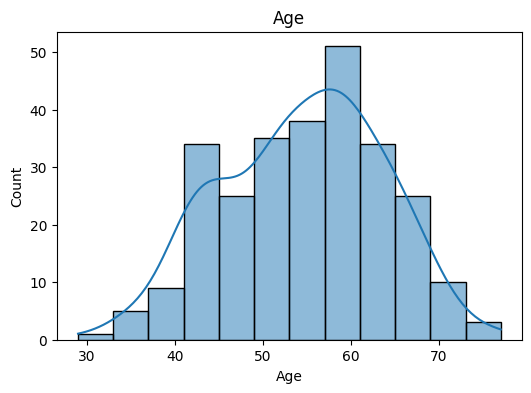

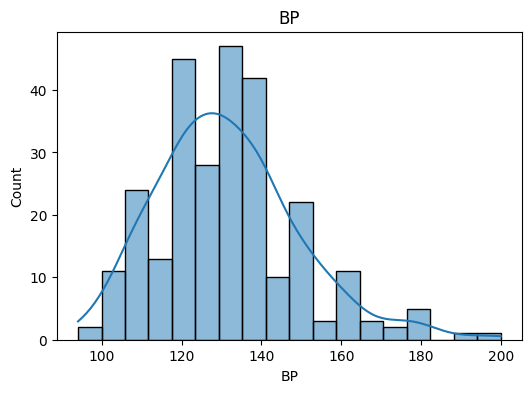

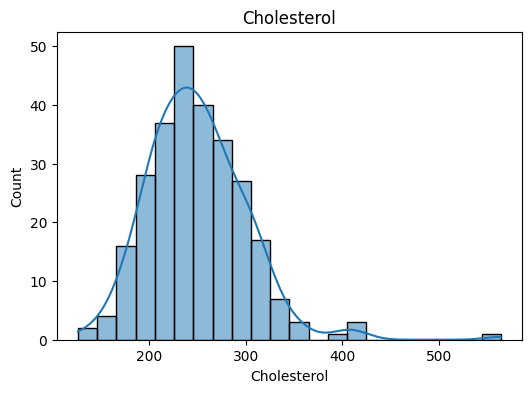

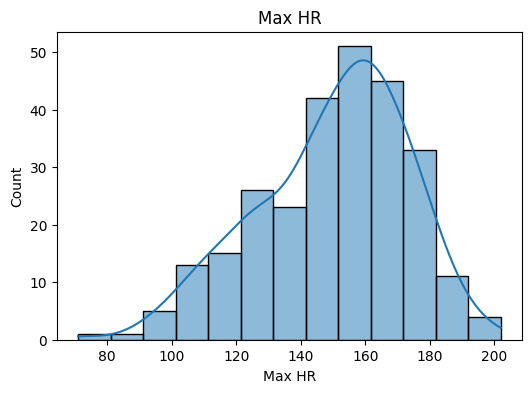

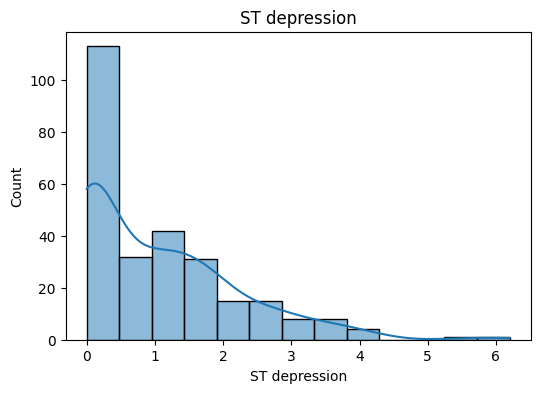

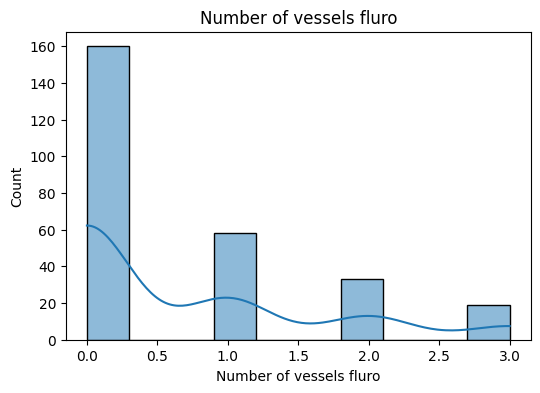

In [7]:
# Univariate analysis : checking the distribution and other stuff of the numerical data
num_cols = ['Age','BP','Cholesterol','Max HR','ST depression','Number of vessels fluro']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.show()

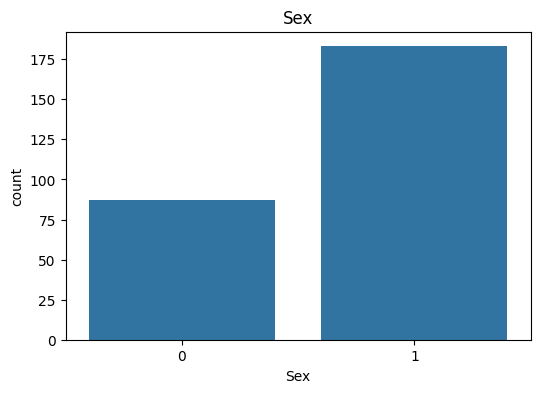

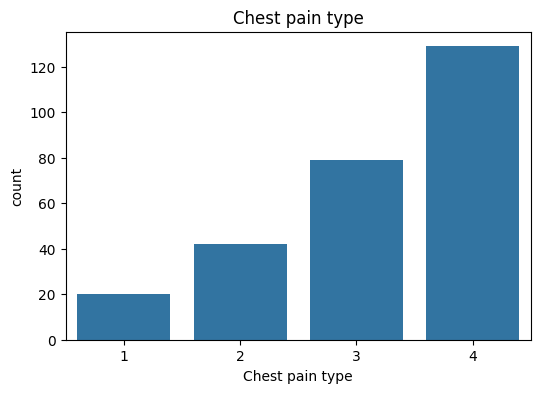

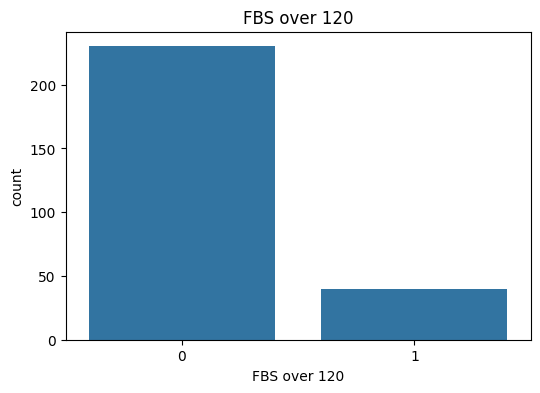

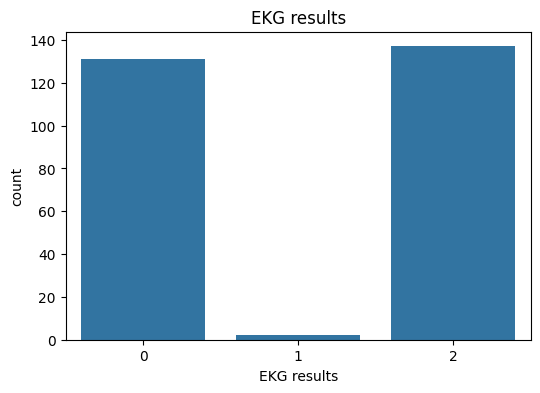

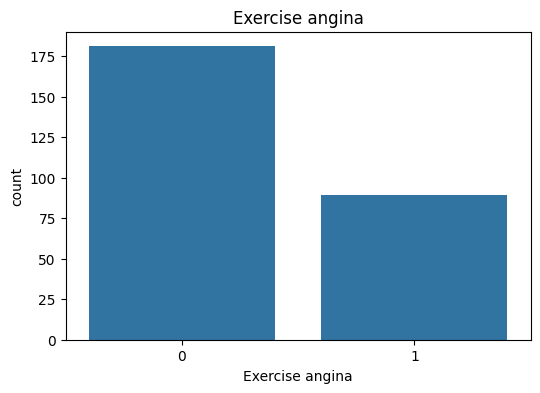

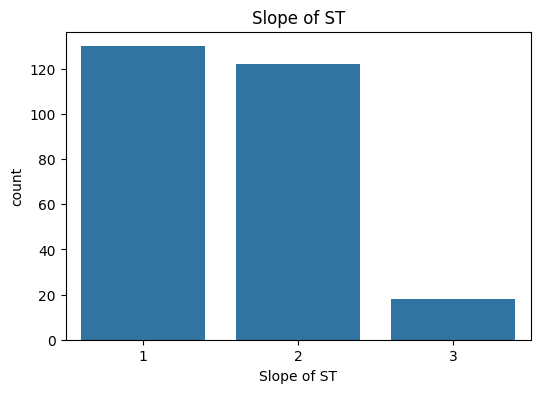

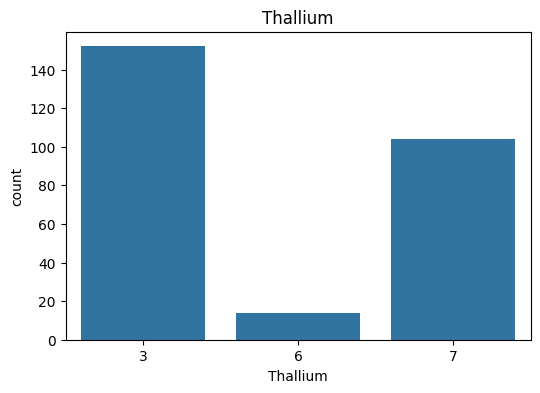

In [8]:
# Univariate analysis : checking the categorical data
cat_cols = ['Sex','Chest pain type','FBS over 120','EKG results','Exercise angina','Slope of ST','Thallium']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,data=df)
    plt.title(col)
    plt.show()

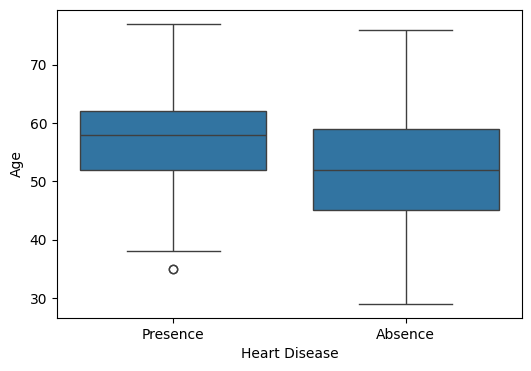

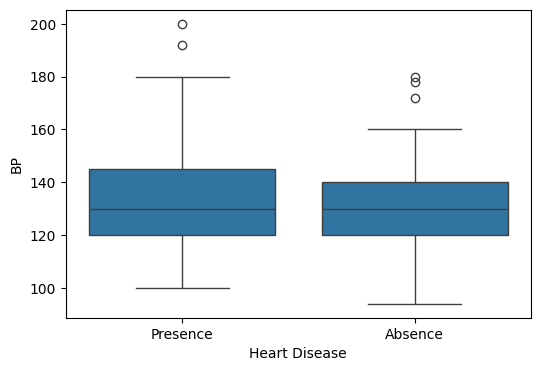

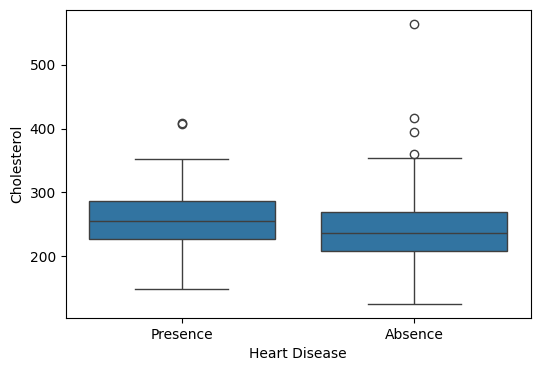

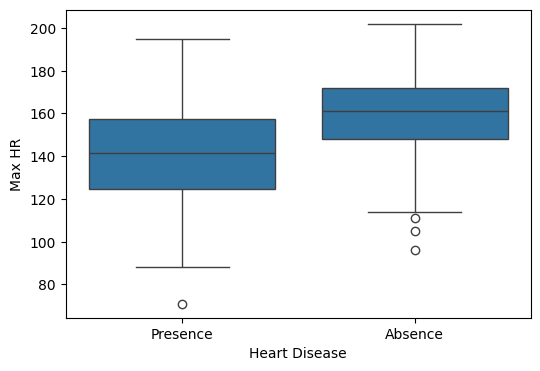

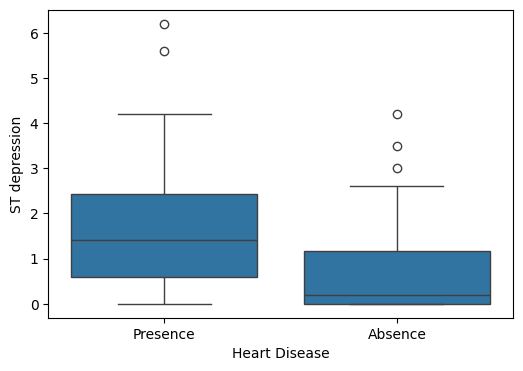

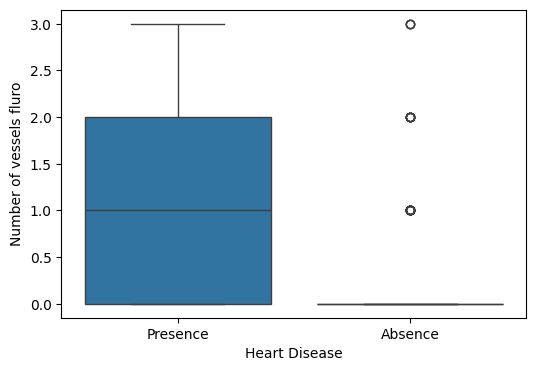

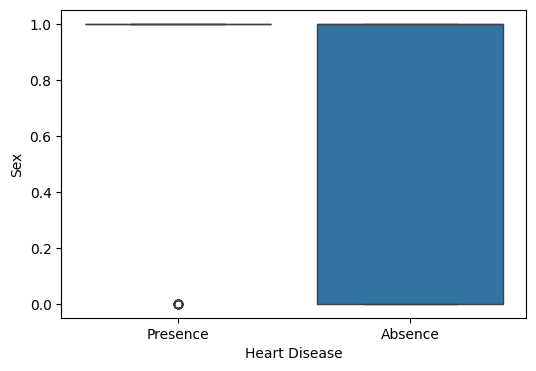

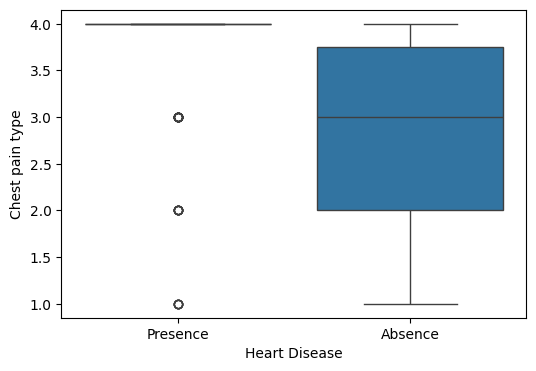

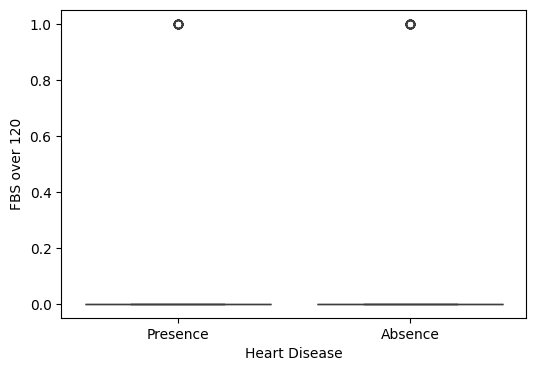

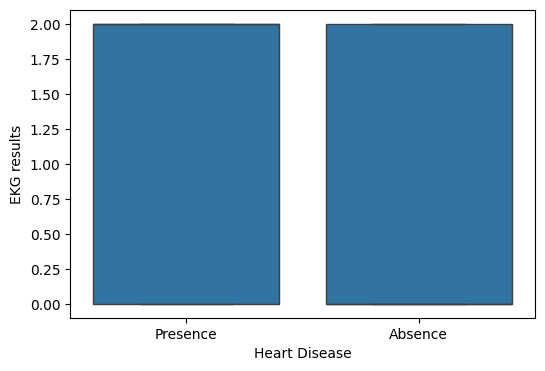

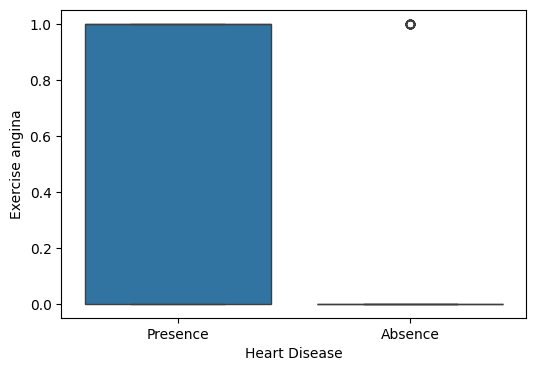

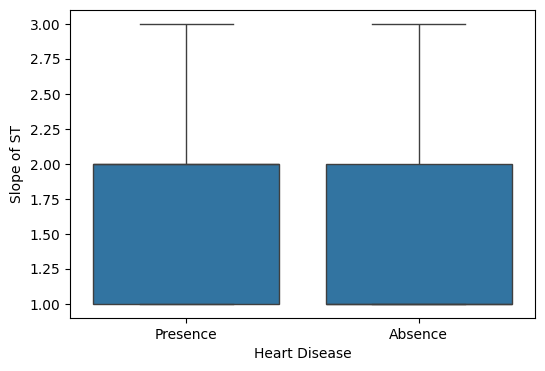

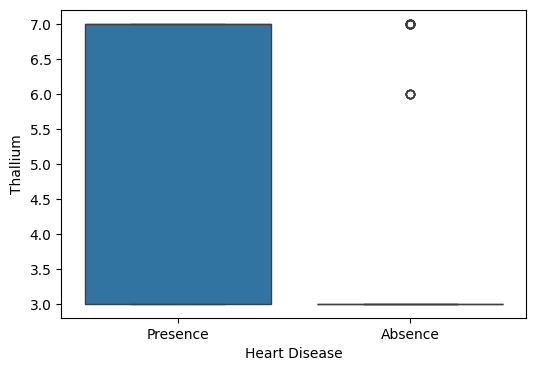

In [9]:
# Bivariate analysis : comparing the target variable with the other features
# Numeric : 
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Heart Disease',y=col,data=df)
    plt.show()

# categorical : 
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Heart Disease',y=col,data=df)
    plt.show()

In [10]:
# converting the categorical column into the numerical col
df['Heart Disease'] = df['Heart Disease'].map({'Presence':1,'Absence':0})
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


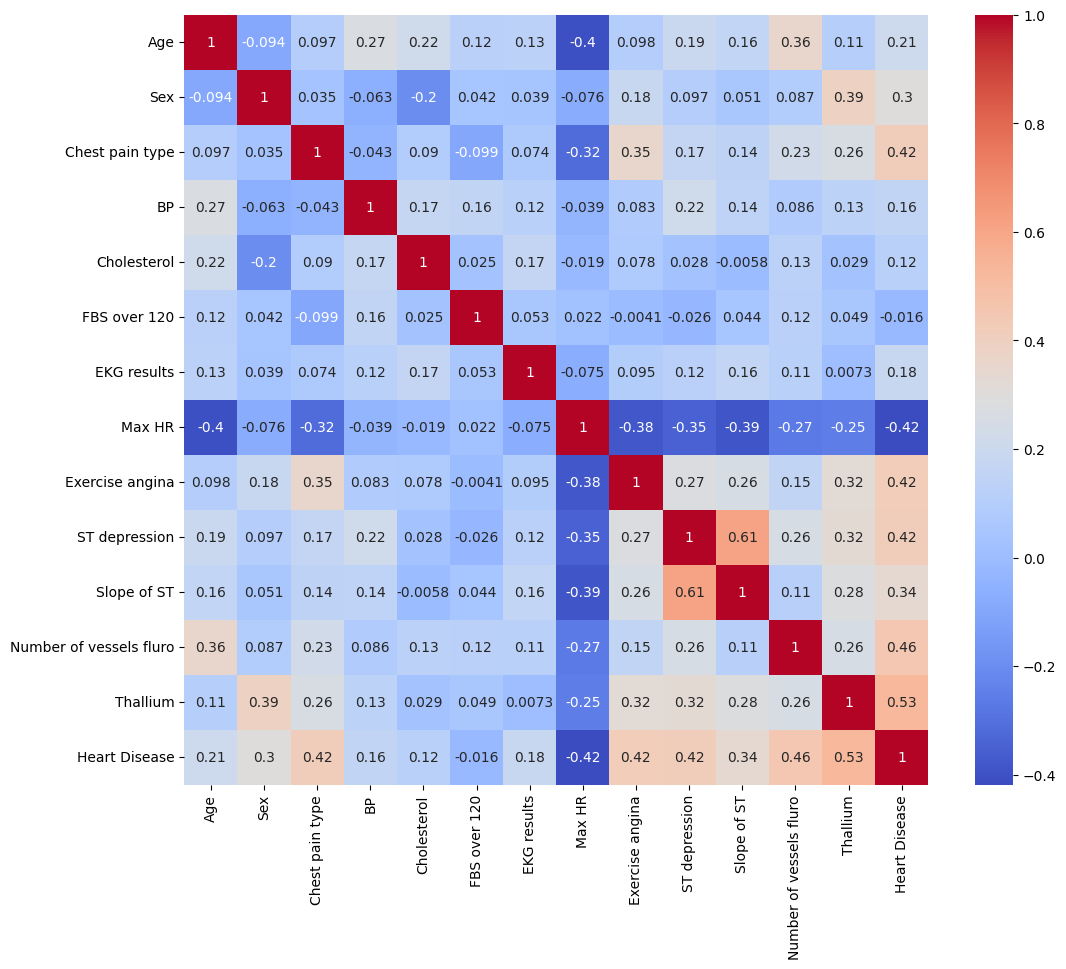

In [11]:
# correlation analysis
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [12]:
# Saving the processed data
df.to_csv("../../data/heart/processed/heart_cleaned.csv", index=False)

#### Standardizing data

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
# splitting data into the input and target datasets
X = df.iloc[:,:-1]
y = df['Heart Disease']

In [15]:
# splitting data into the train and test datasets
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
# getting the numeric feaetures to scale
num_cols = ['Age','BP','Cholesterol','Max HR','ST depression','Number of vessels fluro']

In [17]:
# designing the scaler for the future use as well
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [18]:
# saving the standard scaler model as pkl file
import joblib

joblib.dump(scaler,"../../models/heart/std_scaler.pkl")

['../../models/heart/std_scaler.pkl']